In [1]:
import numpy as np
import scipy.integrate as integrate
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import norm

In [2]:
#cosmological parameters {Euclidean Universe: k = 0}
h = 0.71
Omega_m = 0.3
Omega_Lambda = 0.7
Omega_r = 0
# 1 - Omega_m = Omega_Lambda 

# Define constants
H0 = 100*h  # Hubble constant in km/s/Mpc
c = 299792.458  # Speed of light in km/s

## Cosmological Distances as a Function of Redshift

In [32]:
# Define the Hubble parameter H(z)
def H(z):
    return H0 * np.sqrt(Omega_m * (1 + z)**3 + Omega_Lambda) #+ Omega_r * (1 + z)**4 

# Define the integrand for the comoving distance
def integrand(z):
    return c / H(z)

# Calculate the comoving distance
def comoving_distance(z):
    integral, error = integrate.quad(integrand, 0, z)
    return integral

# Calculate the angular-diameter distance
def angular_diameter_distance(z):
    D_c = comoving_distance(z)
    return D_c / (1 + z) 

# Calculate the luminosity distance
def luminosity_distance(z):
    D_c = comoving_distance(z)
    return D_c * (1 + z)

# Calculate the physical distance between object and observor at the time when light was emitted 
def physical_distance(z):
    return comoving_distance(z)/ (1 + z)
    

In [33]:
# point usage
z = 2

D_c = comoving_distance(z)
D_A = angular_diameter_distance(z)
D_L = luminosity_distance(z)
D_phys = physical_distance(z)

print(f"Comoving Distance at z={z}: {D_c:.3f} Mpc")
print(f"Angular-Diameter Distance at z={z}: {D_A:.3f} Mpc")
print(f"Luminosity Distance at z={z}: {D_L:.3f} Mpc")
print(f"Physical Distance at z={z} when light was emitted: {D_phys:.3f} Mpc")

Comoving Distance at z=2: 5106.906 Mpc
Angular-Diameter Distance at z=2: 1702.302 Mpc
Luminosity Distance at z=2: 15320.719 Mpc
Physical Distance at z=2 when light was emitted: 1702.302 Mpc


In [34]:
# Generate redshift values
# z_values = np.linspace(0.01, 10, 1000)
z_values_1 = np.linspace(0.01, 0.1, 200)
z_values_2 = np.linspace(0.1, 1, 200)
z_values_3 = np.linspace(1, 10, 200)
z_values = np.concatenate((z_values_1, z_values_2, z_values_3)) # Evenly distributed number of points in each order

# Calculate distances
D_c_values = np.array([comoving_distance(z) for z in z_values])
D_A_values = D_c_values / (1 + z_values)
D_L_values = D_c_values * (1 + z_values)

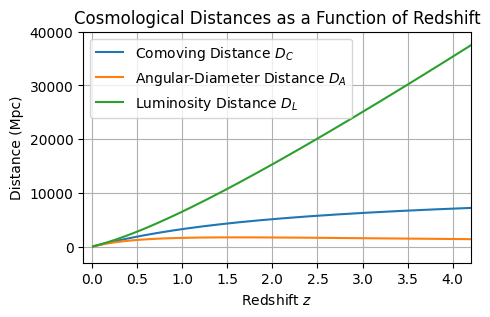

In [35]:
# Plotting
plt.figure(figsize=(5, 3))
plt.plot(z_values, D_c_values, label='Comoving Distance $D_C$')
plt.plot(z_values, D_A_values, label='Angular-Diameter Distance $D_A$')
plt.plot(z_values, D_L_values, label='Luminosity Distance $D_L$')

plt.xlabel('Redshift $z$')
plt.ylabel('Distance (Mpc)')
plt.xlim(-0.1,4.2)
plt.ylim(-3000,40000 )
plt.title('Cosmological Distances as a Function of Redshift')
plt.legend()
plt.grid(True)
plt.show()

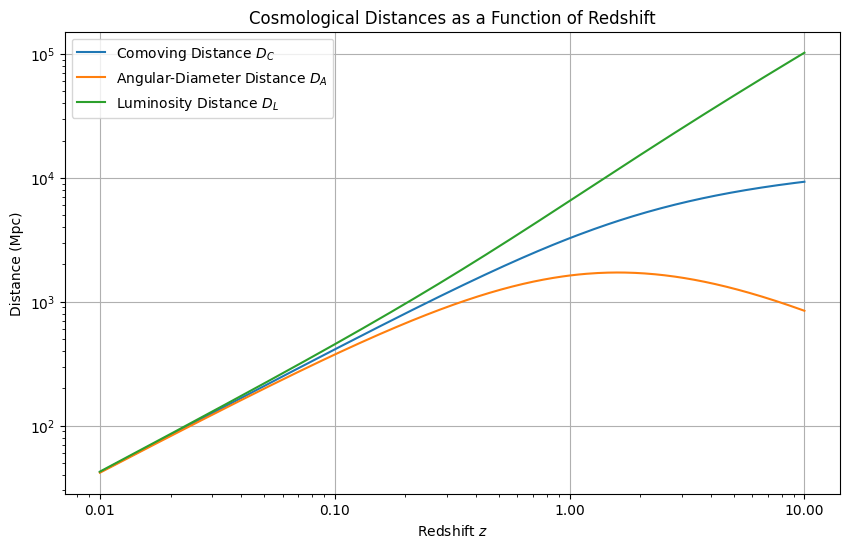

In [36]:
# Plotting Cosmological Distances as a Function of Redshift
plt.figure(figsize=(10, 6))
plt.plot(z_values, D_c_values, label='Comoving Distance $D_C$')
plt.plot(z_values, D_A_values, label='Angular-Diameter Distance $D_A$')
plt.plot(z_values, D_L_values, label='Luminosity Distance $D_L$')

plt.xlabel('Redshift $z$')
plt.ylabel('Distance (Mpc)')
plt.title('Cosmological Distances as a Function of Redshift')
plt.yscale('log')
plt.xscale('log')
plt.legend()
plt.grid(True)
# Set the ticks and format
ax = plt.gca()
ax.set_xticks([0.01, 0.1, 1, 10])
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
plt.show()

## Distance modulus from luminosity distance

In [37]:
# Calculate distance modulus from the Luminosity distance
def distance_modulus(z):
    D_L = luminosity_distance(z)
    return 5*np.log10(D_L) + 25

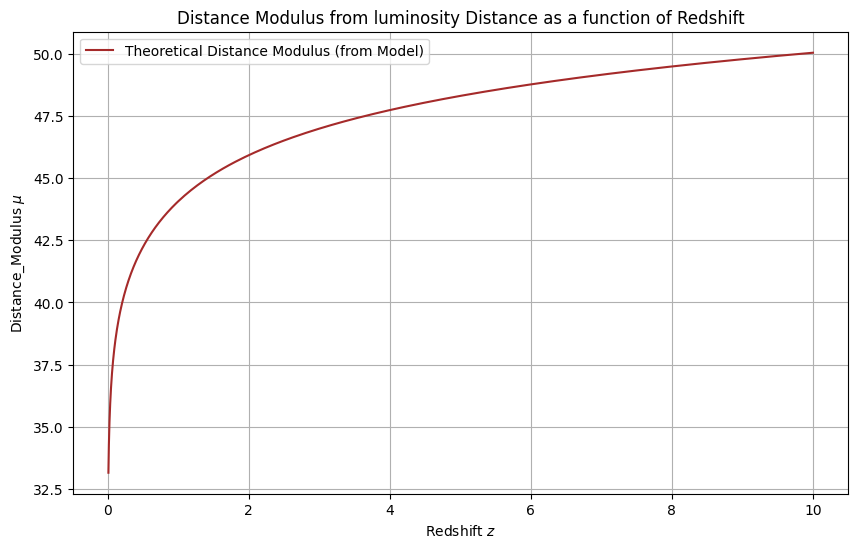

In [38]:
# Plot Distance Modulus from luminosity Distance as a function of Redshift

dist_modulus = np.array([distance_modulus(z) for z in z_values])

plt.figure(figsize=(10, 6))
plt.plot(z_values, dist_modulus, c ='Brown', label = "Theoretical Distance Modulus (from Model)" )
# plt.scatter(z_values, dist_modulus)

plt.xlabel('Redshift $z$')
plt.ylabel(r'Distance_Modulus $\mu$')
plt.title('Distance Modulus from luminosity Distance as a function of Redshift')
plt.grid()
plt.legend()

# plt.xscale('log')
# ax = plt.gca()
# ax.set_xticks([0.01, 0.1, 1, 10])
# ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())

plt.show()

## Open the Supernova data  and plot it on the dist_modulus vs Z plot

In [39]:
# We check if the modified Pantheon_SNdata.csv file is present otherwise we create it
try:
    df = pd.read_csv("Pantheon_SNdata.csv")
    if 'dist_mod' in df.columns: 
        print("The DataFrame has the column 'dist_modulus'.")
    else:
        print('The Dataframe does not have "dist_modulus" column.')
        df['dist_mod'] = df['mb'] + 19.35 # create the distance modulus column m - M( M = - 19.35)
        df.to_csv('Pantheon_SNdata.csv', index= False)

except FileNotFoundError:
    print("Pantheon_SNdata.csv not found")
    df = pd.read_excel("Pantheon - Scolnic SNe 1A 1048 z-asc 27May'19 (2).xlsx")
    print(df.head())
    df.columns = df.iloc[0]
    df = df[1:]
    # Reset the index
    df.reset_index(drop=True, inplace=True)
    print("The DataFrame does not have 'dist_modulus' column.")
    df['dist_mod'] = df['mb'] + 19.35 # create the distance modulus column m - M( M = - 19.35)
    df.to_csv('Pantheon_SNdata.csv', index= False) # save the file

print(df.head())

The DataFrame has the column 'dist_modulus'.
    #name     zcmb     zhel  dz        mb      dmb  dist_mod
0  2002cr  0.01012  0.01012   0  13.90745  0.19825  33.25745
1  2002dp  0.01038  0.01038   0  14.04960  0.20480  33.39960
2  2009an  0.01043  0.01043   0  13.92480  0.20035  33.27480
3  2006bh  0.01082  0.01082   0  14.00860  0.18445  33.35860
4  1998dk  0.01209  0.01209   0  13.97910  0.19140  33.32910


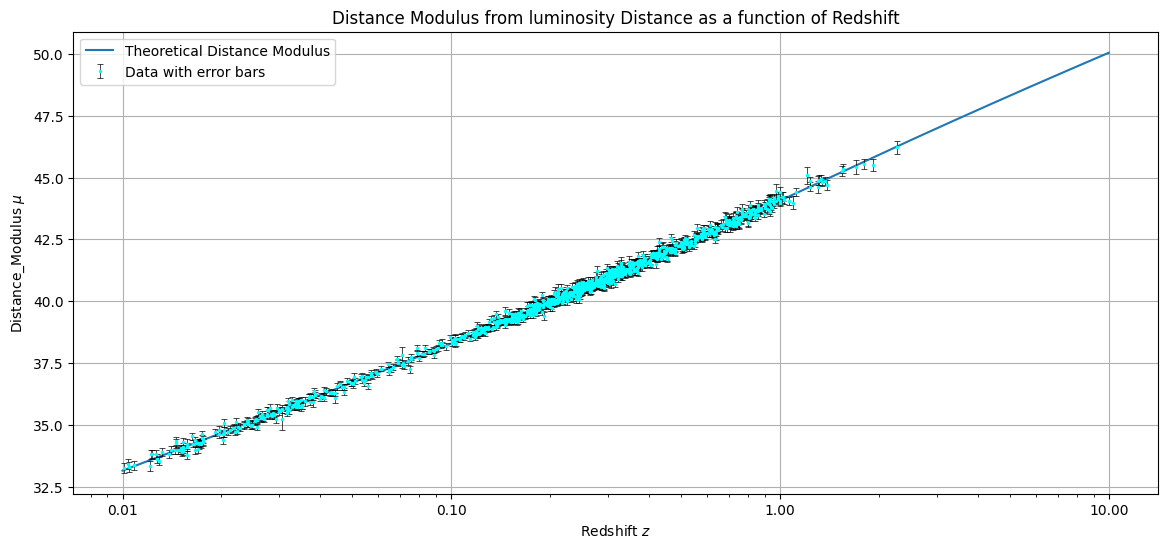

In [40]:
plt.figure(figsize=(14, 6))
plt.plot(z_values, dist_modulus, label = "Theoretical Distance Modulus" )
plt.errorbar(df['zcmb'], df['dist_mod'],  yerr=df['dmb'], fmt='o', mfc ='cyan', mec = 'cyan' ,ms = 1.5, ecolor='black', capsize=2.5, capthick=0.5, elinewidth=0.5, label='Data with error bars')

plt.xlabel('Redshift $z$')
plt.ylabel(r'Distance_Modulus $\mu$')
plt.title('Distance Modulus from luminosity Distance as a function of Redshift')
plt.grid()
plt.legend()

plt.xscale('log')
ax = plt.gca()
ax.set_xticks([0.01, 0.1, 1, 10])
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())

plt.show()
plt.show()

## Define and use the Chi squared function with few examples

In [41]:
# Define Chi squared function
def Chi_squared(observed, theoretical, error):
    observed = np.array(observed)
    theoretical = np.array(theoretical)
    error = np.array(error)
    # Calculate chi-squared 
    chi_squared = np.sum(((observed - theoretical) / error) ** 2)
    return chi_squared    


In [42]:
# Cosmological parameters re-edit to calculate Chi at different H0, omega_m
H0 = 70
Omega_m = 0.3
Omega_Lambda = 1 - Omega_m

chi_sq = Chi_squared(df['dist_mod'] , [distance_modulus(z) for z in df['zcmb']], df['dmb'] )

print(f'Chi Squared value @ H0 = {H0}, omega_m = {Omega_m}: {chi_sq:.3f}')

Chi Squared value @ H0 = 70, omega_m = 0.3: 1037.302


### Chi squared at constant Omaega_m = 0.3
Chi Squared value @ H0 = 70: 1037.302

Chi Squared value @ H0 = 65.0: 2520.378

Chi Squared value @ H0 = 71.0: 1097.867

Chi Squared value @ H0 = 69: 1088.936

Chi Squared value @ H0 = 70.1: 1038.389

Chi Squared value @ H0 = 69.99: 1037.255

Chi Squared value @ H0 = 69.95: 1037.179  /// Minimum value of Xi^2

### Chi squared at constant H0 = 70

Chi Squared value @ H0 = 70, omega_m = 0.3: 1037.302

Chi Squared value @ H0 = 70, omega_m = 0.28: 1038.725

Chi Squared value @ H0 = 70, omega_m = 0.29: 1036.322

Chi Squared value @ H0 = 70, omega_m = 0.292: 1036.251

Chi Squared value @ H0 = 70, omega_m = 0.292: 1036.251 ////// Minimum Value of Xi^2

Chi Squared value @ H0 = 69.95, omega_m = 0.292: 1036.742 ???????????????



# Metropolis Hastings - Markov chain Monte Carlo, to constrain Ωm and H0

In [43]:

# Define the Distance ModulusFunction again to take Ω_m and H0 values
def Hubble(z, H0 = H0, omega_m = Omega_m ):
    return H0 * np.sqrt(omega_m * (1 + z)**3 + 1 - omega_m)
def integrand2(z, H0, omega_m):
    return c / Hubble(z, H0, omega_m)

def DISTANCE_MODULUS(z, H0, omega_m):
    D_c, error = integrate.quad(integrand2, 0, z, args=(H0, omega_m))
    D_L = D_c * (1 + z)
    return 5*np.log10(D_L) + 25


# Calculate omega_m_new, H0_new foe=r each iteration, aso checks if new points are in range
def CALCULATE_NEW(omega_m_previous, H0_previous, delta_omega_m, delta_H0, omega_m_range, H0_range):
    omega_m_new = omega_m_previous + delta_omega_m * np.random.normal(0, 1)
    H0_new = H0_previous + delta_H0 * np.random.normal(0, 1)
    if omega_m_range[0] <= omega_m_new <= omega_m_range[1] and H0_range[0] <= H0_new <= H0_range[1]:
        return omega_m_new, H0_new
    else:
        return CALCULATE_NEW(omega_m_previous, H0_previous, delta_omega_m, delta_H0, omega_m_range, H0_range)
    

In [44]:
# define some constants. parameters
omega_m_range = [0.15, 0.45]
H0_range = [55, 85]
delta_omega_m = 0.005
delta_H0 = 0.2
print(f'\u03A9_m range:{omega_m_range}, \u0394\u03A9_m:{delta_omega_m},\nH0 range:{H0_range}, \u0394H0:{delta_H0}')

N_iterations =100000 #100000

Ω_m range:[0.15, 0.45], ΔΩ_m:0.005,
H0 range:[55, 85], ΔH0:0.2


In [45]:
# Metropolis Hastings - Markov chain Monte Carlo, to constrain Ω_m and H0
mcmc_df = pd.DataFrame(columns=['Omega_m', 'H0', 'Chi_sq', 'Type'])

# choose initial parameters randomly in the range
omega_m_initial = np.random.uniform(low=omega_m_range[0], high=omega_m_range[1])
H0_initial = np.random.uniform(low=H0_range[0], high=H0_range[1])
# H0_initial = 68
# omega_m_initial = 0.44
print("omega_m_initial, H0_initial:", omega_m_initial, H0_initial)

chi_sq = Chi_squared(df['dist_mod'] , [DISTANCE_MODULUS(z, H0_initial, omega_m_initial) for z in df['zcmb']], df['dmb'] )
print("Chi_squared initial:",chi_sq,'\n')

# ------------------------------------------------------------------------------ #

print("Begin MH-MCMC\n")
omega_m_previous = omega_m_initial
H0_previous = H0_initial
chi_sq1 = chi_sq

for n in range(N_iterations):

    omega_m_new, H0_new = CALCULATE_NEW(omega_m_previous, H0_previous, delta_omega_m, delta_H0, omega_m_range, H0_range)
    chi_sq2 = Chi_squared(df['dist_mod'] , [DISTANCE_MODULUS(z, H0_new, omega_m_new) for z in df['zcmb']], df['dmb'] )

    # if n%200 == 0:
    # print( f"{n}) omega_m_new, H0_new:", omega_m_new, H0_new)
        # print("Chi_squared new:",chi_sq2)

    if (chi_sq2 <= chi_sq1):
        omega_m_previous = omega_m_new
        H0_previous = H0_new
        chi_sq1 = chi_sq2
        type_val = 1
        mcmc_df.loc[len(mcmc_df)] = [omega_m_new, H0_new, chi_sq2, type_val]
        print(f'{n})-- type 1, omega_m: {omega_m_previous}, H0 = {H0_previous}, chi_sq: {chi_sq1}')
    else:
        nrand = np.random.uniform(0,1)
        prob_ratio = np.exp(-(chi_sq2 - chi_sq1) / 2)
        if prob_ratio > nrand:
            omega_m_previous = omega_m_new
            H0_previous = H0_new
            chi_sq1 = chi_sq2
            type_val = 2
            mcmc_df.loc[len(mcmc_df)] = [omega_m_new, H0_new, chi_sq2, type_val]
            print(f'{n}) -- type 2, omega_m: {omega_m_previous}, H0 = {H0_previous}, chi_sq: {chi_sq1}')
        else:
            type_val = 3
            # print("----------#type 3: not saved", omega_m_previous, H0_previous, chi_sq1 )

    # mcmc_df.loc[len(mcmc_df)] = [omega_m_new, H0_new, chi_sq2, type_val]


print("\nomega_m_Final, H0_Final:", omega_m_previous, H0_previous)
print('Final Chi_sq value:', chi_sq1)


omega_m_initial, H0_initial: 0.40816940624813447 79.26723188095306
Chi_squared initial: 6904.666180791123 

Begin MH-MCMC

0)-- type 1, omega_m: 0.4047223562609267, H0 = 79.28111848388563, chi_sq: 6865.7507364658995
3)-- type 1, omega_m: 0.4118969820483866, H0 = 79.16859851324048, chi_sq: 6862.613350197372
7)-- type 1, omega_m: 0.4117235765536265, H0 = 78.86798748197617, chi_sq: 6561.672761126221
10)-- type 1, omega_m: 0.40766521943804795, H0 = 78.73070727189004, chi_sq: 6368.026261284062
11)-- type 1, omega_m: 0.40701635940912984, H0 = 78.71414461123365, chi_sq: 6342.535644236968
13)-- type 1, omega_m: 0.40356231138333537, H0 = 78.5487992168205, chi_sq: 6134.478458301175
15)-- type 1, omega_m: 0.403177460776703, H0 = 78.44890603908385, chi_sq: 6034.837023396089
16)-- type 1, omega_m: 0.3974834701160045, H0 = 78.06938806620636, chi_sq: 5606.094897694615
18)-- type 1, omega_m: 0.3976323400803724, H0 = 77.93455170038398, chi_sq: 5487.287271675451
21)-- type 1, omega_m: 0.4016527309492865

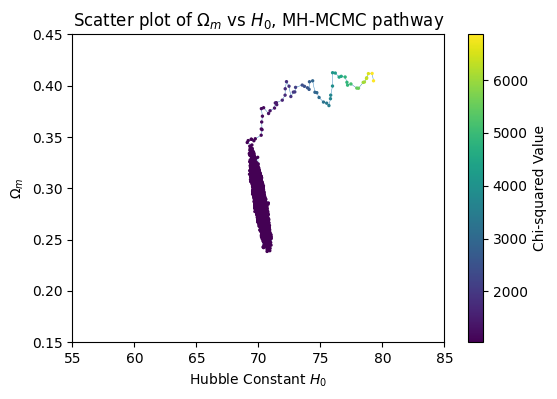

In [46]:
# Scatter plot of Ω_m vs H_0 MH-MCMC pathway
plt.figure(figsize=(6, 4))
plt.plot(mcmc_df['H0'], mcmc_df['Omega_m'], linewidth =0.3, zorder=1)
plt.scatter(mcmc_df['H0'], mcmc_df['Omega_m'], c=mcmc_df['Chi_sq'], cmap='viridis', s = 2, zorder=2)
plt.colorbar(label='Chi-squared Value')
plt.xlabel('Hubble Constant $H_0$')
plt.ylabel('$\u03A9_m$')
plt.title('Scatter plot of $\u03A9_m$ vs $H_0$, MH-MCMC pathway')

plt.xlim(H0_range[0], H0_range[1])
plt.ylim(omega_m_range[0], omega_m_range[1])

plt.show()

In [47]:

# mcmc_df = pd.read_csv("mcmc100000@260624.csv")
print(mcmc_df.head())


#Trim mcmc values to remove burnt values
final_chi_sq = mcmc_df['Chi_sq'].iloc[-1]
# Find the first row where Chi_sq is less than the threshold
first_valid_index = mcmc_df[mcmc_df['Chi_sq'] < 1.1*final_chi_sq].index[0]
print(first_valid_index)

# Trim the DataFrame from the first valid index onward
mcmc_df = mcmc_df.iloc[first_valid_index:].reset_index(drop=True)

print(mcmc_df)


    Omega_m         H0       Chi_sq  Type
0  0.404722  79.281118  6865.750736   1.0
1  0.411897  79.168599  6862.613350   1.0
2  0.411724  78.867987  6561.672761   1.0
3  0.407665  78.730707  6368.026261   1.0
4  0.407016  78.714145  6342.535644   1.0
51
        Omega_m         H0       Chi_sq  Type
0      0.357126  70.293560  1133.499375   1.0
1      0.357812  70.230620  1127.568997   1.0
2      0.351725  70.220953  1112.979992   1.0
3      0.348261  69.744971  1069.837925   1.0
4      0.346333  69.631810  1062.815131   1.0
...         ...        ...          ...   ...
54110  0.301220  69.760948  1039.158367   2.0
54111  0.305293  69.855108  1038.396027   1.0
54112  0.307303  69.748294  1039.523379   2.0
54113  0.304197  69.762542  1039.093018   1.0
54114  0.303524  69.677597  1040.853256   2.0

[54115 rows x 4 columns]


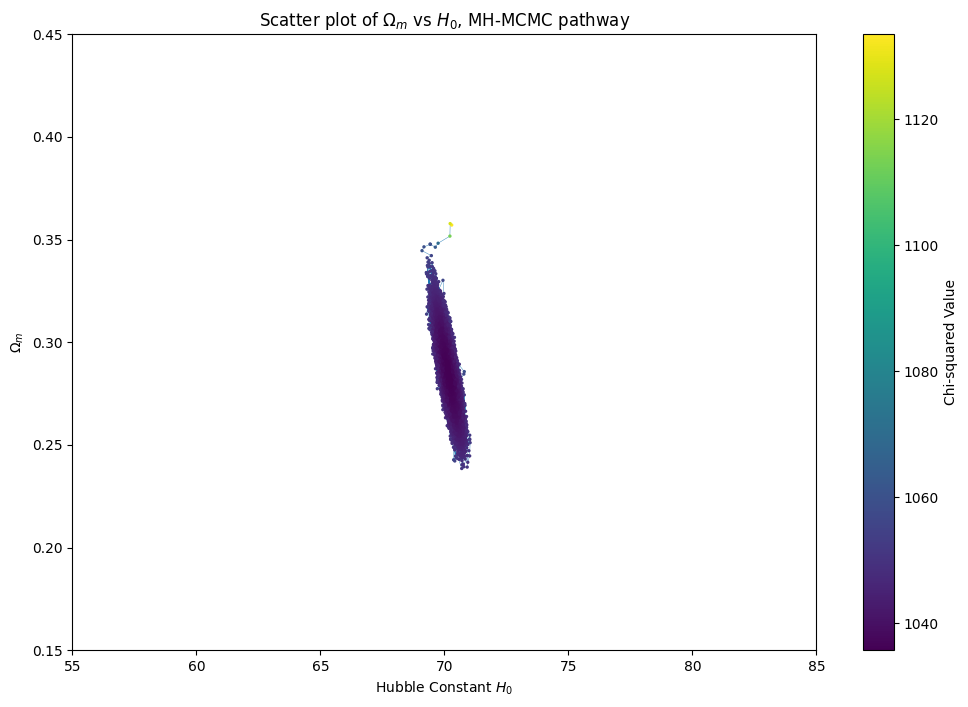

In [48]:
# Scatter plot of Ω_m vs H_0 MH-MCMC pathway
plt.figure(figsize=(12, 8))
plt.plot(mcmc_df['H0'], mcmc_df['Omega_m'], linewidth =0.3, zorder=1)
plt.scatter(mcmc_df['H0'], mcmc_df['Omega_m'], c=mcmc_df['Chi_sq'], cmap='viridis', s = 2, zorder=2)
plt.colorbar(label='Chi-squared Value')
plt.xlabel('Hubble Constant $H_0$')
plt.ylabel('$\u03A9_m$')
plt.title('Scatter plot of $\u03A9_m$ vs $H_0$, MH-MCMC pathway')

plt.xlim(H0_range[0], H0_range[1])
plt.ylim(omega_m_range[0], omega_m_range[1])

plt.show()

bins_omega_m:
 [0.15  0.155 0.16  0.165 0.17  0.175 0.18  0.185 0.19  0.195 0.2   0.205
 0.21  0.215 0.22  0.225 0.23  0.235 0.24  0.245 0.25  0.255 0.26  0.265
 0.27  0.275 0.28  0.285 0.29  0.295 0.3   0.305 0.31  0.315 0.32  0.325
 0.33  0.335 0.34  0.345 0.35  0.355 0.36  0.365 0.37  0.375 0.38  0.385
 0.39  0.395 0.4   0.405 0.41  0.415 0.42  0.425 0.43  0.435 0.44  0.445
 0.45 ]
Best gaussian Fit μ = 0.28495294019137923, std =0.012503857628125378
Maximum count value: 8587.0


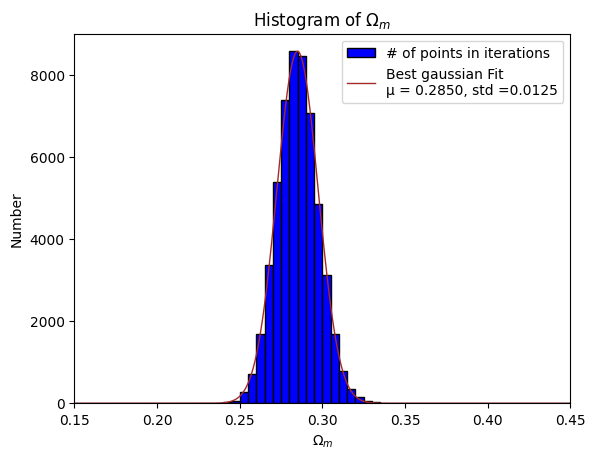

In [49]:
# Plot the Histogram for Number of values oin given Omega_m bins
bins_omega_m = np.linspace(omega_m_range[0], omega_m_range[1], int((omega_m_range[1] - omega_m_range[0])/delta_omega_m)+1 )

# Find the best gaussian fit to the histogram
mu_omegam, std_omegam = norm.fit(mcmc_df['Omega_m'])
A = 1 / (std_omegam * np.sqrt(2 * np.pi))

# Plot the Histogram
counts, bins, _ = plt.hist(mcmc_df['Omega_m'], bins= bins_omega_m, color='blue', edgecolor='black', label = '# of points in iterations')
max_count = counts.max()
# Plot the Gaussian Fit
x = np.linspace(omega_m_range[0], omega_m_range[1], 1000)
p = norm.pdf(x, mu_omegam, std_omegam)
gaussian = plt.plot(x, p*max_count/A, c ='Brown', linewidth=1, label = f'Best gaussian Fit \n\u03BC = {mu_omegam:.4f}, std ={std_omegam:.4f}')


print("bins_omega_m:\n",bins_omega_m)
print(f'Best gaussian Fit \u03BC = {mu_omegam}, std ={std_omegam}')
print(f"Maximum count value: {max_count}")

plt.xlabel('$\u03A9_m$')
plt.ylabel('Number')
plt.xlim(omega_m_range[0], omega_m_range[1])
plt.title('Histogram of $\u03A9_m$')
plt.legend()
plt.show()

bins_H0:  [55.  55.2 55.4 55.6 55.8 56.  56.2 56.4 56.6 56.8 57.  57.2 57.4 57.6
 57.8 58.  58.2 58.4 58.6 58.8 59.  59.2 59.4 59.6 59.8 60.  60.2 60.4
 60.6 60.8 61.  61.2 61.4 61.6 61.8 62.  62.2 62.4 62.6 62.8 63.  63.2
 63.4 63.6 63.8 64.  64.2 64.4 64.6 64.8 65.  65.2 65.4 65.6 65.8 66.
 66.2 66.4 66.6 66.8 67.  67.2 67.4 67.6 67.8 68.  68.2 68.4 68.6 68.8
 69.  69.2 69.4 69.6 69.8 70.  70.2 70.4 70.6 70.8 71.  71.2 71.4 71.6
 71.8 72.  72.2 72.4 72.6 72.8 73.  73.2 73.4 73.6 73.8 74.  74.2 74.4
 74.6 74.8 75.  75.2 75.4 75.6 75.8 76.  76.2 76.4 76.6 76.8 77.  77.2
 77.4 77.6 77.8 78.  78.2 78.4 78.6 78.8 79.  79.2 79.4 79.6 79.8 80.
 80.2 80.4 80.6 80.8 81.  81.2 81.4 81.6 81.8 82.  82.2 82.4 82.6 82.8
 83.  83.2 83.4 83.6 83.8 84.  84.2 84.4 84.6 84.8 85. ]
Best gaussian Fit μ = 70.16054700845093, std =0.21994365842003358
Maximum count value: 18236.0


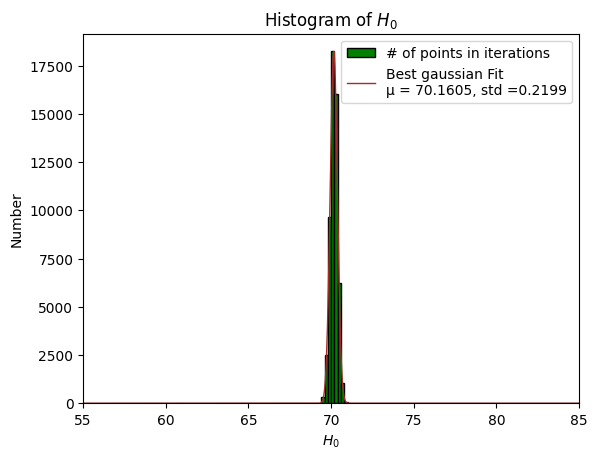

In [50]:
bins_H0 = np.linspace(H0_range[0], H0_range[1], int((H0_range[1]- H0_range[0])/delta_H0)+1 )

# Find the best gaussian fit to the histogram
mu_H0, std_H0 = norm.fit(mcmc_df['H0'])
A = 1 / (std_H0 * np.sqrt(2 * np.pi))

# Plot the Histogram
counts, bins, _ = plt.hist(mcmc_df['H0'], bins=bins_H0, color='green', edgecolor='black', label = '# of points in iterations')
max_count = counts.max()
# Plot the Gaussian Fit
x = np.linspace(H0_range[0], H0_range[1], 1000)
p = norm.pdf(x, mu_H0, std_H0)
gaussian = plt.plot(x, p*max_count/A, c ='Brown',linewidth=1, label = f'Best gaussian Fit \n\u03BC = {mu_H0:.4f}, std ={std_H0:.4f}')

print("bins_H0: ",bins_H0)
print(f'Best gaussian Fit \u03BC = {mu_H0}, std ={std_H0}')
print(f"Maximum count value: {max_count}")

plt.xlabel('$H_0$')
plt.ylabel('Number')
plt.xlim(H0_range[0], H0_range[1])
plt.title('Histogram of $H_0$')
plt.legend()
plt.show()

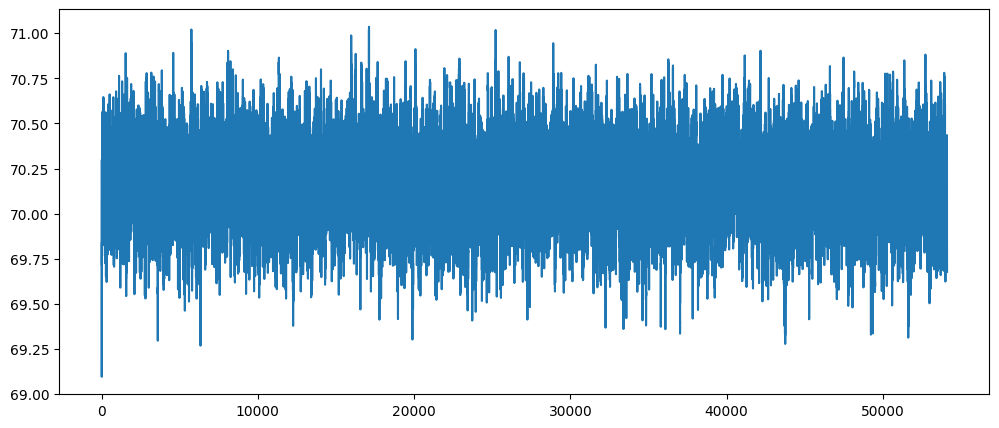

In [51]:
plt.figure(figsize=(12, 5))
plt.plot(mcmc_df['H0'], label = 'H0 values')
plt.show()

### Best Fits
1)mcmc10000@250624.csv  
omega_m = Best gaussian Fit μ = 0.2849754296374409, std =0.013449608205127871  
H0 = Best gaussian Fit μ = 70.16704581539307, std =0.543204221555191  
   
2)mcmc10000[0.1]@250624.csv  
omega_m = Best gaussian Fit μ = 0.28961594267286617, std =0.016053867250583175  
H0 = Best gaussian Fit μ = 70.13306437517241, std =0.44874702104037467 


3.0) 260624  
Best gaussian Fit μ = 0.30254649535112343, std =0.03540352515271726  
Best gaussian Fit μ = 69.949626443604, std =0.6800128076161743  
  

3.1) mcmc10000@260624.csv  
Omega_m = Best gaussian Fit μ = 0.2813249853347482, std =0.012788741889072133   
H0 = Best gaussian Fit μ = 70.20988535987603, std =0.2334663260899012   


4)mcmc100000@260624.csv /// BEST YET   
Omega_m = Best gaussian Fit μ = 0.2844559079291173, std =0.012752536445318693   
H0 = Best gaussian Fit μ = 70.16887004344073, std =0.2340284468632038    

5)mcmc10000[0.2]@260624.csv   
omega_m = Best gaussian Fit μ = 0.2864110455997517, std =0.013610489619491637   
H0 = Best gaussian Fit μ = 70.1412285756219, std =0.23591860089160424

6)
Best gaussian Fit μ = 70.15224494817537, std =0.22796882882488967

## Save the mcmc_df data to a csv file 

In [ ]:
# mcmc_df.to_csv(f"mcmc{N_iterations}[{delta_H0},{delta_omega_m}]@260624.csv", index = False)

In [55]:
print(f"mcmc{N_iterations}[{delta_H0},{delta_omega_m}]@010726")
print(f'Best gaussian Fit \u03BC = {mu_H0}, std ={std_H0}')
print(f'Best gaussian Fit \u03BC = {mu_omegam}, std ={std_omegam}')

mcmc100000[0.2,0.005]@010726
Best gaussian Fit μ = 70.16054700845093, std =0.21994365842003358
Best gaussian Fit μ = 0.28495294019137923, std =0.012503857628125378
